In [2]:
import pandas as pd
import requests
import json
from datetime import datetime, timedelta

import sys, os
sys.path.append(os.path.abspath("../src"))

In [35]:
import time

from tqdm import tqdm


API = "https://en.wikipedia.org/w/api.php"
HEADERS = {"User-Agent": "thinking-bee/0.1 (t.j.wies@gmail.com)"}

def get_template_links(template_title: str) -> list[str]:
    params = {
        "action": "query",
        "format": "json",
        "prop": "links",
        "titles": template_title,
        "pllimit": "max",
        "plnamespace": 0,   # main/article namespace only
        "formatversion": 2,
    }

    titles = []
    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=20)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages:
            links = pages[0].get("links", [])
            titles.extend(link["title"] for link in links)

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    return sorted(set(titles))

def get_revision_diff(parent_id, rev_id):
    params = {
        "action": "compare",
        "format": "json",
        "fromrev": parent_id,
        "torev": rev_id,
        "prop": "diff|ids|title",
        "formatversion": "2",
    }

    resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    compare = data.get("compare", {})
    return compare.get("*") or compare.get("body") or compare.get("diff")


def get_revisions(page_title, talk=False, include_diff=False, sleep_sec=0.0):
    if talk and not page_title.startswith("Talk:"):
        page_title = "Talk:" + page_title

    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": page_title,
        "rvprop": "ids|timestamp|user|comment|size",
        "rvlimit": "max",
        "formatversion": "2",
    }

    all_revisions = []

    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages and "revisions" in pages[0]:
            all_revisions.extend(pages[0]["revisions"])

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    df = pd.DataFrame(all_revisions)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["page_title"] = page_title

    if include_diff:
        diffs = []
        for _, row in df.iterrows():
            rev_id = row.get("revid")
            parent_id = row.get("parentid")

            if pd.isna(rev_id) or pd.isna(parent_id) or parent_id == 0:
                diffs.append(None)
            else:
                try:
                    diff_html = get_revision_diff(int(parent_id), int(rev_id))
                    diffs.append(diff_html)
                    if sleep_sec > 0:
                        time.sleep(sleep_sec)
                except Exception:
                    diffs.append(None)

        df["diff_html"] = diffs

    df["comment"] = df["comment"].fillna("")
    df["comment_len"] = df["comment"].str.len()
    df["has_reply"] = df["comment"].str.contains("Reply", case=False, regex=False).astype(int)
    df["has_revert"] = df["comment"].str.contains("revert", case=False, regex=True).astype(int)
    df["size_change"] = df["size"].diff().abs()

    return df

def format_revisions(revisions):

    if revisions is None:
        return pd.DataFrame()
    if revisions.empty:
        return revisions
    df = revisions
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df["timestamp"] = df["timestamp"].dt.floor("h")
    edits = df.groupby("timestamp").size().rename("edits")
    unique_editors = df.groupby("timestamp")["user"].nunique().rename("unique_editors")

    df["seen_before"] = df["user"].duplicated()
    df["new_editor"] = (~df["seen_before"]).astype(int)
    new_editors = df.groupby("timestamp")["new_editor"].sum().rename("new_editors")
    total_comment_len = df.groupby("timestamp")["comment_len"].sum().rename("total_comment_len")
    num_replies = df.groupby("timestamp")["has_reply"].sum().rename("num_replies")
    num_reverts = df.groupby("timestamp")["has_revert"].sum().rename("num_reverts")
    features = pd.concat([edits, unique_editors, new_editors, total_comment_len, num_replies, num_reverts], axis=1).fillna(0)

    return features.reset_index().sort_values("timestamp")

In [ ]:
titles = get_template_links("Template:Campaignbox 2026 Iran war")
from tqdm import tqdm
all_revisions = []
features = pd.DataFrame()
for i in tqdm(titles):
    rev = get_revisions(i, talk=False, include_diff=False, sleep_sec=0)
    talk_rev = get_revisions(i, talk=True, include_diff=False, sleep_sec=0)

    if not rev.empty:
        all_revisions.append(rev)
    if not talk_rev.empty:
        all_revisions.append(talk_rev)

    
all_revisions = pd.concat(all_revisions)
all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

# clean + sort
all_revisions["timestamp"] = pd.to_datetime(all_revisions["timestamp"], utc=True)
all_revisions = all_revisions.sort_values("timestamp")

revisions = format_revisions(all_revisions)

# GLOBAL new editors (across ALL pages)
all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

# comment features
all_revisions["comment"] = all_revisions["comment"].fillna("")
all_revisions["comment_len"] = all_revisions["comment"].str.len()
all_revisions["has_reply"] = all_revisions["comment"].str.contains("Reply", case=False).astype(int)
all_revisions["has_revert"] = all_revisions["comment"].str.contains("revert", case=False).astype(int)

# size change (global ordering matters here too)
all_revisions["size_change"] = all_revisions["size"].diff().abs()

# floor timestamps to hour
all_revisions["timestamp"] = all_revisions["timestamp"].dt.floor("h")

features = all_revisions.groupby("timestamp").agg(
    edits=("user", "count"),
    unique_editors=("user", "nunique"),
    new_editors=("new_editor_global", "sum"),
    total_comment_len=("comment_len", "sum"),
    num_replies=("has_reply", "sum"),
    num_reverts=("has_revert", "sum"),
).reset_index().sort_values("timestamp")

In [6]:
import importlib
import poly_utils
importlib.reload(poly_utils)
from poly_utils import search_event_slugs

slugs = search_event_slugs("Iran")
print(slugs)

[{'slug': 'us-x-iran-ceasefire-extended-by', 'title': 'US x Iran ceasefire extended by...?', 'active': True, 'closed': False, 'volume': 101025965.58342908, 'liquidity': 9091764.52575}, {'slug': 'trump-announces-end-of-military-operations-against-iran-by', 'title': 'Trump announces end of military operations against Iran by ...?', 'active': True, 'closed': False, 'volume': 39024803.018714875, 'liquidity': 394363.44905}, {'slug': 'us-x-iran-permanent-peace-deal-by', 'title': 'US x Iran permanent peace deal by...?', 'active': True, 'closed': False, 'volume': 61325644.22060546, 'liquidity': 1505547.28869}, {'slug': 'us-x-iran-diplomatic-meeting-by-329', 'title': 'US x Iran diplomatic meeting by...?', 'active': True, 'closed': False, 'volume': 26679849.744722907, 'liquidity': 589357.57962}, {'slug': 'will-the-us-invade-iran-before-2027', 'title': 'Will the U.S. invade Iran before 2027?', 'active': True, 'closed': False, 'volume': 18225597.12735837, 'liquidity': 597396.2876}]


In [ ]:
from src.poly_utils import get_price_series_from_slug, get_event_slugs

slugs = get_event_slugs("Israel")
print(slugs)

prices, meta = get_price_series_from_slug(
    slug=slug,
    days=60,
    chunk_days=7,
    interval="1h",
    fidelity=60,
)

print(meta)
print(prices.head())
print(prices.tail())
print(f"Rows returned: {len(prices)}")

ImportError: cannot import name 'get_event_slugs' from 'poly_utils' (/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/src/poly_utils.py)

In [5]:
# --- BASIC CHECKS ---
print("Rows:", len(prices))
print("Time range:", prices["timestamp"].min(), "→", prices["timestamp"].max())

# --- SORT + CLEAN ---
prices = prices.sort_values("timestamp").drop_duplicates("timestamp")

# --- CHECK FOR GAPS ---
prices["delta"] = prices["timestamp"].diff()

print("\nUnique time deltas:")
print(prices["delta"].value_counts().head())

# --- EXPECTED FREQUENCY CHECK (1h) ---
expected = pd.Timedelta("1h")
gaps = prices[prices["delta"] > expected]

print(f"\nNumber of gaps > 1h: {len(gaps)}")

if len(gaps) > 0:
    print("\nExample gaps:")
    print(gaps[["timestamp", "delta"]].head())

# --- CHECK FOR DUPLICATES ---
dupes = prices["timestamp"].duplicated().sum()
print("\nDuplicate timestamps:", dupes)

# --- RESAMPLE TO CLEAN GRID ---
prices_clean = (
    prices.set_index("timestamp")
    .resample("1h")
    .last()   # 👈 use last observed price
    .ffill()
    .reset_index()
)

print("\nAfter resampling:")
print("Rows:", len(prices_clean))

# --- FINAL SANITY ---
print("\nFinal time delta check:")
print(prices_clean["timestamp"].diff().value_counts().head())

Rows: 1399
Time range: 2026-02-28 01:00:21+00:00 → 2026-04-29 00:28:03+00:00

Unique time deltas:
delta
0 days 01:00:00    207
0 days 01:00:01    184
0 days 00:59:59    158
0 days 01:00:02    105
0 days 00:59:58     94
Name: count, dtype: int64

Number of gaps > 1h: 632

Example gaps:
                  timestamp           delta
1 2026-02-28 02:00:25+00:00 0 days 01:00:04
3 2026-02-28 04:00:22+00:00 0 days 01:00:01
5 2026-02-28 06:00:25+00:00 0 days 01:00:03
7 2026-02-28 08:00:31+00:00 0 days 01:00:08
9 2026-02-28 10:00:25+00:00 0 days 01:00:04

Duplicate timestamps: 0

After resampling:
Rows: 1440

Final time delta check:
timestamp
0 days 01:00:00    1439
Name: count, dtype: int64


In [6]:
features.head()

,timestamp,edits,unique_editors,new_editors,total_comment_len,num_replies,num_reverts
0,2003-08-26 06:00:00+00:00,5,3,3,28,0,0
1,2003-08-27 14:00:00+00:00,2,2,1,13,0,0
2,2003-08-27 16:00:00+00:00,2,1,0,0,0,0
3,2003-09-03 04:00:00+00:00,1,1,1,36,0,0
4,2003-11-22 00:00:00+00:00,1,1,1,26,0,0


In [7]:
prices_hourly = (
    prices.set_index("timestamp")
    .resample("1h")
    .mean()
    .ffill()
    .reset_index()
)

features_hourly = (
    features.set_index("timestamp")
    .resample("1h")
    .sum()
    .fillna(0)
    .reset_index()
)

df = pd.merge_asof(
    prices_hourly.sort_values("timestamp"),
    features_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")
windows = ["30min", "1h", "3h", "6h", "12h", "24h"]
df = df.copy()
for w in windows:
    df[f"edits_{w}"] = df["edits"].rolling(w).mean()
    df[f"edits_{w}_diff"] = df[f"edits_{w}"].diff()
    df[f"delta_price_{w}"] = df["price"].shift(-int(w[0])) - df["price"]
    df[f"abs_delta_price_move_{w}"] = df[f"delta_price_{w}"].abs()
    df[f"unique_editors_{w}"] = df["unique_editors"].rolling(w).mean()
    df[f"new_editors_{w}"] = df["new_editors"].rolling(w).mean()
    df[f"total_comment_len_{w}"] = df['total_comment_len'].rolling(w).mean()
    df[f"num_replies_{w}"] = df['num_replies'].rolling(w).mean()
    df[f"num_reverts_{w}"] = df['num_reverts'].rolling(w).mean()
    df["returns"] = df["price"].pct_change()
    df[f"volatility_{w}"] = df["returns"].rolling(w).std()

In [8]:
df.shape

(1440, 69)

In [10]:
import matplotlib.pyplot as plt

def plot_rolling_delta(col1: str, col2: str):
    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(df.index, df[col1], label=col1)
    ax1.set_ylabel(col1)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df[col2], color="orange", alpha=0.6, label=col2)
    ax2.set_ylabel(col2)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title(f"{col1} vs {col2}")
    plt.show()


# plot_rolling_delta("volatility_6h", "total_comment_len_lag_3")

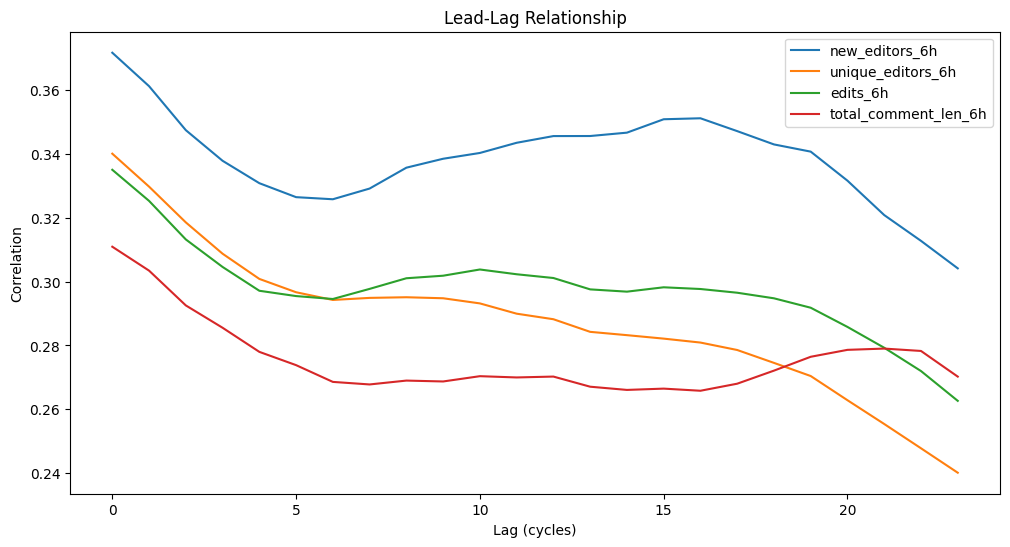

In [18]:
corrs = []
df["target"] = df["volatility_6h"].shift(-1)
for lag in range(0, 24):
    shifted = df["new_editors_6h"].shift(lag)
    corr = shifted.corr(df["target"])
    corrs.append(corr)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(range(24), corrs, label="new_editors_6h")

for col in ["unique_editors_6h", "edits_6h", "total_comment_len_6h"]:
    corrs_col = []
    for lag in range(0, 24):
        shifted = df[col].shift(lag)
        corr = shifted.corr(df["target"])
        corrs_col.append(corr)
    plt.plot(range(24), corrs_col, label=col)

plt.legend()
plt.xlabel("Lag (cycles)")
plt.ylabel("Correlation")
plt.title("Lead-Lag Relationship")
plt.show()

In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = df.copy()

# -----------------------------
# Target: future volatility
# -----------------------------
df["target"] = df["volatility_6h"].shift(-1)

# -----------------------------
# Lag + memory features
# -----------------------------
max_lag = 24
feature_cols = []
categories = ["edits", "new_editors", "unique_editors", "total_comment_len"]
for w in windows:
    for cat in categories:
        cat += "_" + w
        for i in range(1, max_lag + 1):
            col = f"{cat}_lag_{i}"
            df[col] = df[cat].shift(i)
            feature_cols.append(col)

        # IMPORTANT: shift before EWM to avoid current-hour leakage
        category_past = df[cat].shift(1)

        for alpha in [0.2, 0.5, 0.8]:
            col = f"{cat}_ewm_{alpha}"
            df[col] = category_past.ewm(alpha=alpha, adjust=False).mean()
            feature_cols.append(col)
df = df.copy()

# -----------------------------
# Clean model frame
# -----------------------------
model_df = pd.concat([df[feature_cols], df["target"]], axis=1).dropna()

split = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split].copy()
test_df = model_df.iloc[split:].copy()

# Threshold from train only
threshold = train_df["target"].quantile(0.8)

train_df["big_move"] = (train_df["target"] > threshold).astype(int)
test_df["big_move"] = (test_df["target"] > threshold).astype(int)

print("Train class counts:")
print(train_df["big_move"].value_counts())

print("\nTest class counts:")
print(test_df["big_move"].value_counts())

if train_df["big_move"].nunique() < 2:
    raise ValueError("Training set has only one class. Lower threshold or get more data.")

# -----------------------------
# Train/test
# -----------------------------
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["big_move"]
y_test = test_df["big_move"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)
print("\nAUC:", auc)

# -----------------------------
# Learned lag weights
# -----------------------------
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": model.coef_[0]
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients:")
print(coef_df.head(10))

print("\nTop negative coefficients:")
print(coef_df.tail(10))

Train class counts:
big_move
0    792
1    198
Name: count, dtype: int64

Test class counts:
big_move
0    331
1     94
Name: count, dtype: int64

AUC: 0.6445972873947419

Top positive coefficients:
                          feature      coef
639  total_comment_len_24h_lag_19  0.726218
585        new_editors_24h_lag_19  0.667716
638  total_comment_len_24h_lag_18  0.603179
640  total_comment_len_24h_lag_20  0.595078
558              edits_24h_lag_19  0.547725
637  total_comment_len_24h_lag_17  0.512915
586        new_editors_24h_lag_20  0.467004
533  total_comment_len_12h_lag_21  0.413992
532  total_comment_len_12h_lag_20  0.408772
557              edits_24h_lag_18  0.395462

Top negative coefficients:
                          feature      coef
507     unique_editors_12h_lag_22 -0.316337
448              edits_12h_lag_17 -0.330415
449              edits_12h_lag_18 -0.351391
617     unique_editors_24h_lag_24 -0.372085
508     unique_editors_12h_lag_23 -0.386650
562              edits_24

In [ ]:
y_train_shuffled = y_train.sample(frac=1, random_state=42)

model.fit(X_train_scaled, y_train_shuffled)
y_pred_prob_shuffled = model.predict_proba(X_test_scaled)[:, 1]

print("Shuffled AUC:", roc_auc_score(y_test, y_pred_prob_shuffled))

Shuffled AUC: 0.5076171498360866


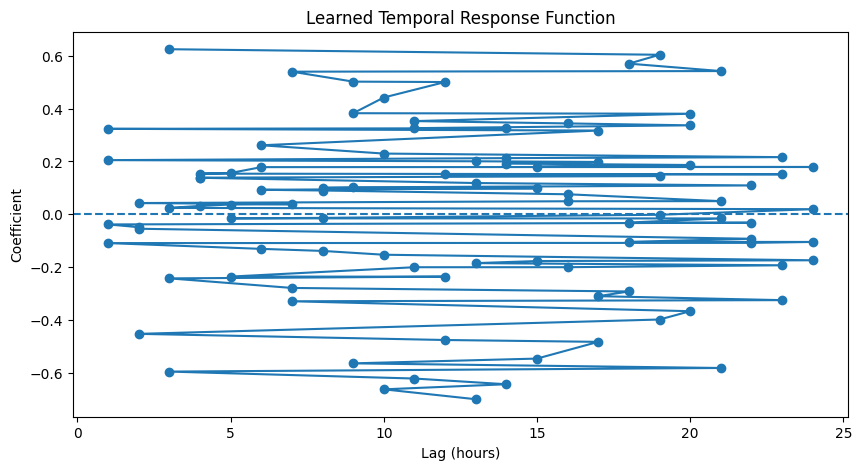

In [ ]:
import matplotlib.pyplot as plt

lags = [int(f.split("_")[-1]) for f in coef_df["feature"] if "lag" in f]
coefs = coef_df[coef_df["feature"].str.contains("lag")]["coef"].values

plt.figure(figsize=(10,5))
plt.plot(lags, coefs, marker='o')
plt.axhline(0, linestyle="--")
plt.xlabel("Lag (hours)")
plt.ylabel("Coefficient")
plt.title("Learned Temporal Response Function")
plt.show()